In [ ]:
!pip install xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, classification_report

from xgboost import XGBClassifier

In [ ]:
# Load data
train = pd.read_excel("TRAIN.xlsx")
test = pd.read_excel("TEST.xlsx")

In [ ]:
# Shape
print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

# Info
print(train.info())

Train Shape: (54808, 14)
Test Shape: (23490, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  KPIs_met >80%         54808 non-null  int64  
 11  awards_won?           54808 non-null  int64  
 12  avg_training_score    54808 non-null  int64  
 13  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(

In [ ]:
# Missing values
print("\nMissing Values:\n", train.isnull().sum())


Missing Values:
 employee_id                0
department                 0
region                     0
education               2409
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    4124
length_of_service          0
KPIs_met >80%              0
awards_won?                0
avg_training_score         0
is_promoted                0
dtype: int64


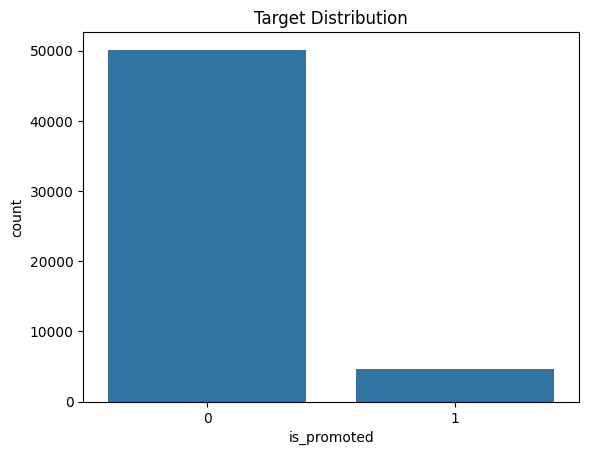

In [ ]:
# Target distribution
sns.countplot(x='is_promoted', data=train)
plt.title("Target Distribution")
plt.show()

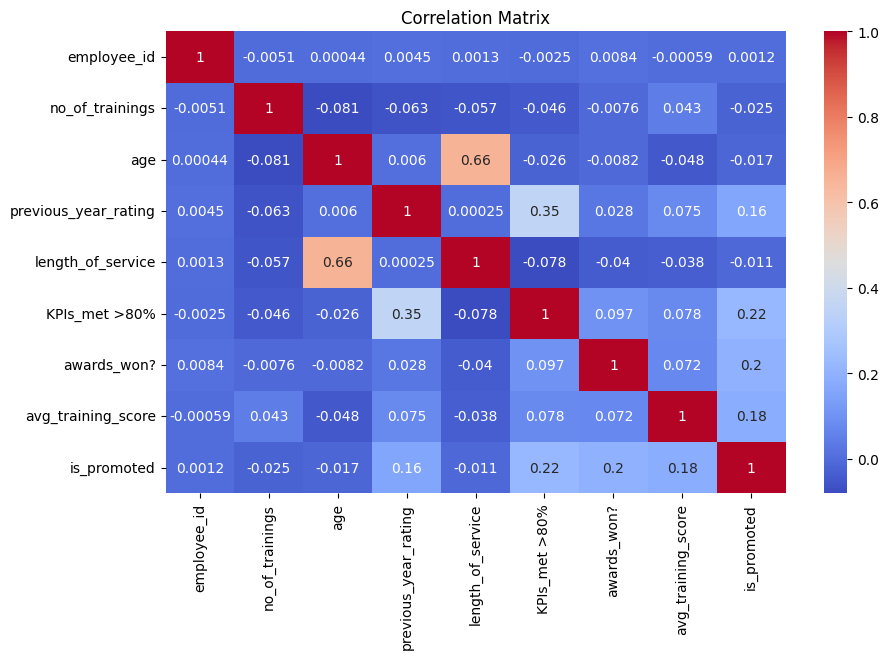

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(train.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [ ]:
def feature_engineering(df):
    df = df.copy()

    df['experience'] = df['age'] - df['length_of_service']
    df['training_per_year'] = df['no_of_trainings'] / (df['length_of_service'] + 1)
    df['avg_kpi'] = (df['KPIs_met >80%'] + df['awards_won?']) / 2

    return df

train = feature_engineering(train)
test = feature_engineering(test)

In [ ]:
#PREPROCESSING
train_df = train.copy()
test_df = test.copy()

# Separate target
y = train_df['is_promoted']
train_df = train_df.drop(columns=['is_promoted'])


In [ ]:
# Combining for preprocessing only
full = pd.concat([train_df, test_df])

In [ ]:
# Fill missing values (NO DROPPING)
for col in full.columns:
    if full[col].dtype == 'object':
        full[col] = full[col].fillna(full[col].mode()[0])
    else:
        full[col] = full[col].fillna(full[col].median())

In [ ]:
# Encode categorical variables
cat_cols = full.select_dtypes(include='object').columns

In [ ]:
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    full[col] = le.fit_transform(full[col])
    le_dict[col] = le

In [ ]:
# Split back
X_train = full.iloc[:len(train_df), :]
X_test = full.iloc[len(train_df):, :]

In [ ]:
#train test split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
#XGboost classifier
model = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

model.fit(X_tr, y_tr)

# Validation prediction
y_probs = model.predict_proba(X_val)[:, 1]
y_pred = (y_probs > 0.5).astype(int)

print("Baseline F1:", f1_score(y_val, y_pred))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:32:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Baseline F1: 0.5087853323147441


In [ ]:
#finetuning
param_grid = {
    'n_estimators': [200, 300, 400],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1],
    'colsample_bytree': [0.7, 0.8, 1],
    'scale_pos_weight': [5, 10, 15]
}

xgb = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

In [ ]:
search = RandomizedSearchCV(
    xgb,
    param_distributions=param_grid,
    n_iter=10,
    scoring='f1',
    cv=3,
    verbose=1,
    n_jobs=-1
)

search.fit(X_tr, y_tr)

best_model = search.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:34:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
#threshold tuning
y_probs = best_model.predict_proba(X_val)[:, 1]

best_f1 = 0
best_thresh = 0.5

for t in np.arange(0.2, 0.6, 0.05):
    preds = (y_probs > t).astype(int)
    score = f1_score(y_val, preds)

    if score > best_f1:
        best_f1 = score
        best_thresh = t

print("Best Threshold:", best_thresh)
print("Best F1:", best_f1)

Best Threshold: 0.5499999999999999
Best F1: 0.4952076677316294


In [ ]:
#final prediction
test_probs = best_model.predict_proba(X_test)[:, 1]
test_preds = (test_probs > best_thresh).astype(int)

In [ ]:
#submission file
submission = pd.DataFrame({
    'employee_id': test['employee_id'],
    'is_promoted': test_preds
})

submission.to_csv("submission.csv", index=False)

In [ ]:
#downloading
from google.colab import files
files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>